In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Part 1: Data Profiling and Preparation

In [155]:
listings = pd.read_csv("Data/Listings.csv", encoding="unicode-escape", dtype={"host_response_time" : "str", "district" : "str"}) 
# I added dtype parameter as the two columns presents missing values. Therefore, Pandas raised the mixed type warning.

In [156]:
#print(listings.info())
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [157]:
listings["host_since"] = pd.to_datetime(listings["host_since"])

#print(listings["host_is_superhost"].dropna().unique())
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"] # transform in False True boolean
for col in bool_cols:
    listings[col] = listings[col].map({"f" : False, "t" : True, np.nan : np.nan}).astype("bool")
    
#listings["host_location"].unique()

Listings refer to several cities, but we are interested only in Paris. The new dataframe includes 64,690 observations with only 33 missing values in the `host_since` column, representing less than 1% of the total rows. Duplicates represent about 3%, but this is not an accurate measure due to the exclusion of several columns. Indeed, the original dataset has no duplicates.

**Descriptive statistics**

- The host with the most years of experience has been on the platform since August 2008, and the newest one since July 2021.

- In Paris, facilities can host about 3 people on average, and a maximum of 16. The minimum number of accommodations is 0, which is weird. This may be due to an error.

- Regarding prices, people pay 113 euros on average. However, this is not an accurate estimate, since the maximum price is 12000 per night, which indicates the presence of outliers. In these cases, it's recommended to look at the median, represented by the 50th percentile, which is 80 euros per night. As before, the minimum is 0. This is something worth investigating further.

In [158]:
paris_listings = listings.loc[listings["city"] == "Paris", ["listing_id", "host_since", "neighbourhood", "accommodates", "price",]]
print("Missing values\n", round(paris_listings.isna().mean() * 100,2))
paris_listings.describe().round(2)

Missing values
 listing_id       0.00
host_since       0.05
neighbourhood    0.00
accommodates     0.00
price            0.00
dtype: float64


,listing_id,host_since,accommodates,price
count,64690.00,64657,64690.00,64690.00
mean,24236859.60,2015-11-01 11:06:05.528867,3.04,113.10
min,2577.00,2008-08-30 00:00:00,0.00,0.00
25%,11809610.00,2014-03-09 00:00:00,2.00,59.00
50%,23948499.50,2015-07-07 00:00:00,2.00,80.00
75%,37207979.50,2017-05-29 00:00:00,4.00,120.00
max,48091852.00,2021-02-07 00:00:00,16.00,12000.00
std,14326572.88,NaN,1.59,214.43


Now I investigate those listings that indicate 0 accommodations and 0 price. It turns out that there are 62 observations like this, all of which are hotel rooms. The only common feature I identified is the significant number of missing values in the review and host-statistics variables, with most having 100% missing data. This is probably due to errors in data entry. Since these observations represent less than 1% of the total Paris listing, I will exclude them as it's unlikely they will distort the estimates.

62 0.096


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
98209,44312919,Bienvenue ÃÂ l'HÃÂ´tel des 3 CollÃÂ¨ges,357400186,2020-07-20,FR,NaN,NaN,NaN,False,0.0,...,1,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
203257,43012882,Timhotel Paris Berthier,333365314,2020-02-04,FR,within an hour,1.0,1.00,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
203258,43035744,Le Pigalle,100008960,2016-10-17,"Paris, Ile-de-France, France",within an hour,1.0,1.00,False,7.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
203259,43274767,Hotel MAYET,344545473,2020-04-24,FR,within an hour,1.0,1.00,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
203260,43274785,Hotel AUGUSTE,344545592,2020-04-24,FR,within an hour,1.0,1.00,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208881,46000461,HOTEL LES DAMES DU PANTHEON,372878700,2020-10-22,FR,NaN,NaN,NaN,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
208882,46652813,OKKO HOTELS Paris Gare de l'Est ****,377087064,2020-11-26,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
208883,46652882,OKKO HOTELS Paris Portes de Versailles ****,377087788,2020-11-26,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
208884,47169609,Pavillon Porte de Versailles,381040883,2020-12-21,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,0.0,...,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


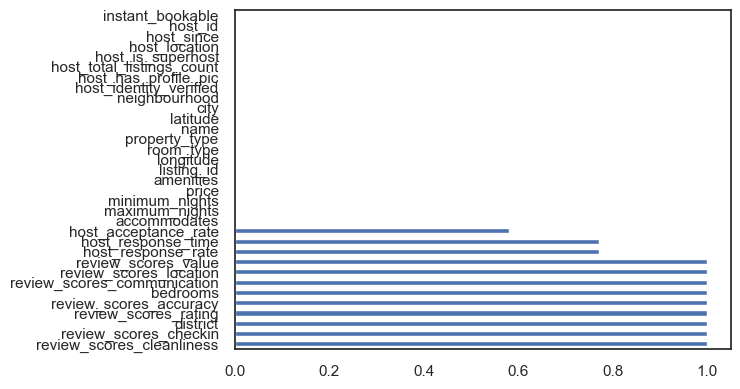

In [159]:
listings_check = listings.loc[listings["city"] == "Paris"].query("accommodates == 0 or price == 0")
print(listings_check.shape[0], round(listings_check.shape[0]/paris_listings.shape[0]*100,3)) # (Observations, On total)
(listings_check.isna().mean().round(2)).sort_values(ascending=False).plot.barh()
listings_check

In [160]:
paris_listings = paris_listings.loc[~paris_listings["listing_id"].isin(listings_check["listing_id"])]

# Part 2: Preparing Data for Visualization

In [161]:
paris_listings_neighbourhood = paris_listings.groupby("neighbourhood").agg(mean_price = ("price", "mean")).sort_values("mean_price", ascending=False)
most_expensive_neigh = paris_listings_neighbourhood.query("mean_price == mean_price.max()").index[0]



In [162]:
paris_listings_accomodations = (paris_listings.query("neighbourhood == @most_expensive_neigh")
                                .groupby("accommodates").agg(mean_price = ("price", "mean"))
                                .sort_values("mean_price", ascending=False))

In [163]:
paris_listings_over_time = (paris_listings.set_index("host_since")
                            .resample("YE")
                            .agg(mean_price=("price", "mean"), host_count = ("listing_id", "count"))
                            .assign(new_hosts = lambda x : x["host_count"].diff(1)))

paris_listings_over_time

,mean_price,host_count,new_hosts
host_since,,,
2008-12-31,77.750000,4,NaN
2009-12-31,159.641509,106,102.0
2010-12-31,125.031250,416,310.0
2011-12-31,124.828230,1339,923.0
2012-12-31,111.578615,4592,3253.0
2013-12-31,107.096414,8142,3550.0
2014-12-31,100.253800,10922,2780.0
2015-12-31,103.646250,12147,1225.0
2016-12-31,114.211345,8867,-3280.0


# Part 3: Visualization

Text(0.5, 1.0, 'Average listing price by neighbourhood')

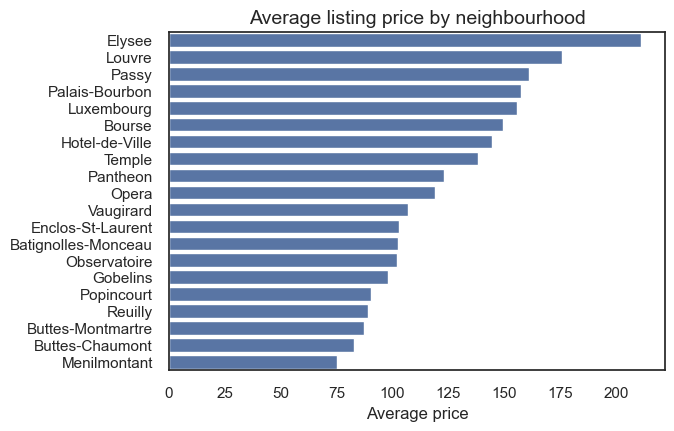

In [164]:
sns.set_theme(style="white", rc={"font.family" : "sans-serif", "font.sans-serif" : "Arial", "axes.titlesize" : 14})
sns.barplot(data=paris_listings_neighbourhood, x="mean_price", y="neighbourhood")
plt.xlabel("Average price")
plt.ylabel(None)
plt.title("Average listing price by neighbourhood")

Text(0.5, 1.0, 'Average listing price by number of accomodations')

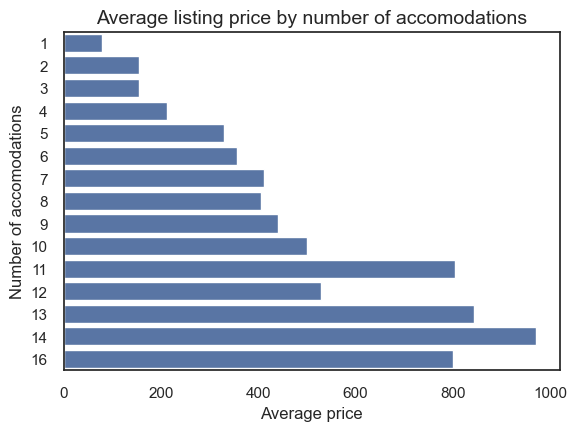

In [165]:
sns.barplot(data=paris_listings_accomodations, x="mean_price", y="accommodates", orient="h")
plt.xlabel("Average price")
plt.ylabel("Number of accomodations")
plt.title("Average listing price by number of accomodations")

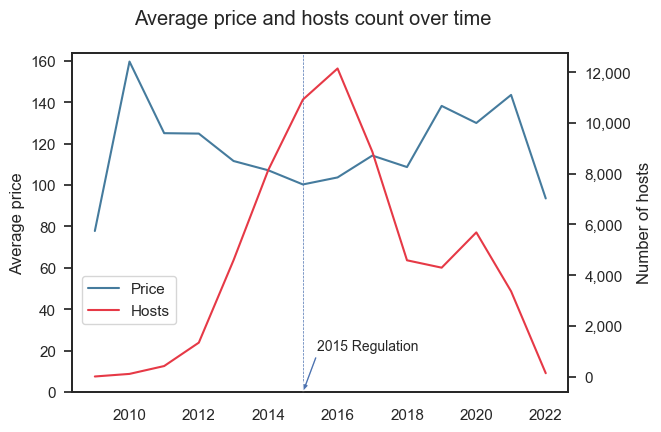

In [166]:
fig, ax1 = plt.subplots(1,1)
ax2 = ax1.twinx()
line1 = ax1.plot(paris_listings_over_time.index, paris_listings_over_time["mean_price"], color="#457b9d", label="Price")
line2 = ax2.plot(paris_listings_over_time.index, paris_listings_over_time["host_count"], color="#e63946", label="Hosts")
ax1.set_ylabel("Average price")
ax2.set_ylabel("Number of hosts")
ax2.yaxis.set_major_formatter("{x:,.0f}")
plt.suptitle("Average price and hosts count over time")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc=(0.02, 0.2))

line_date = datetime.datetime(2015, 1, 1)
ax1.axvline(line_date, linestyle="dashed", linewidth=0.5)
ax1.annotate(text="2015 Regulation", xy=(line_date,0), fontsize=10, xytext=(datetime.datetime(2015, 6, 1), 20), arrowprops={"headwidth" : 5, "width" : 2, "headlength" : 6})

ax1.set_ylim(0)
plt.show()


The charts show that the regulation, taken place after Airbnb had already become extremely popular, determined a sharp decrease in the number of hosts over the next two years, but also an increase in average price due to lower competition, excluding the Covid period.